In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning
import sweetviz as sv
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df["PhoneService"].unique())
print(df['MultipleLines'].unique())
print(df['Partner'].unique())
print(df['SeniorCitizen'].unique())
print(df['gender'].unique())
print(df['OnlineSecurity'].unique())
print(df['OnlineBackup'].unique())
print(df['DeviceProtection'].unique())
print(df['TechSupport'].unique())
print(df['StreamingTV'].unique())
print(df['StreamingMovies'].unique())
print(df['PaperlessBilling'].unique())
print(df['Churn'].unique())
print(df['Dependents'].unique())
print(df['InternetService'].unique())
print(df['PaymentMethod'].unique())

['No' 'Yes']
['No phone service' 'No' 'Yes']
['Yes' 'No']
[0 1]
['Female' 'Male']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['DSL' 'Fiber optic' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [5]:
yes_no_no_service_cols = [col for col in df.columns
               if set(df[col].dropna().unique()) <= {'Yes', 'No','No internet service'}]
print(yes_no_no_service_cols)

for col in yes_no_no_service_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service':0})

male_female_column = [col for col in df.columns
               if set(df[col].dropna().unique()) <= {'Female', 'Male'}]
for col in male_female_column:
    df[col] = df[col].map({'Male': 1, 'Female': 0})

['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']


In [6]:
print(df.columns.tolist())
print(df.select_dtypes(include='object').columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
['customerID', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod', 'TotalCharges']


In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# 1. تبدیل TotalCharges (اگر قبلاً انجام ندادی)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. ستون‌هایی که باید One-Hot بشن
one_hot_columns = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', encoder, one_hot_columns)
    ],
    remainder='passthrough'
)

# 3. Fit + Transform
transformed_data = preprocessor.fit_transform(df)

# 4. ساخت اسم ستون‌ها
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(one_hot_columns)
remainder_columns = [col for col in df.columns if col not in one_hot_columns]
all_feature_names = list(onehot_feature_names) + remainder_columns

# 5. ساخت DataFrame نهایی
df_processed = pd.DataFrame(transformed_data, columns=all_feature_names, index=df.index)

# 6. تبدیل همه به عدد
df_processed = df_processed.astype(float)

In [9]:
df_processed.head()

,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,29.85,29.85,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,56.95,1889.50,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,53.85,108.15,1.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,42.30,1840.75,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,70.70,151.65,1.0


In [ ]:
report = sv.analyze(df)
report.show_html("sweetviz_report2ـ.html")

In [11]:
df = df_processed.copy()

In [12]:
df.shape

(7043, 25)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   MultipleLines_No phone service         7043 non-null   float64
 1   MultipleLines_Yes                      7043 non-null   float64
 2   InternetService_Fiber optic            7043 non-null   float64
 3   InternetService_No                     7043 non-null   float64
 4   Contract_One year                      7043 non-null   float64
 5   Contract_Two year                      7043 non-null   float64
 6   PaymentMethod_Credit card (automatic)  7043 non-null   float64
 7   PaymentMethod_Electronic check         7043 non-null   float64
 8   PaymentMethod_Mailed check             7043 non-null   float64
 9   gender                                 7043 non-null   float64
 10  SeniorCitizen                          7043 non-null   float64
 11  Part

In [14]:
df.dtypes

MultipleLines_No phone service           float64
MultipleLines_Yes                        float64
InternetService_Fiber optic              float64
InternetService_No                       float64
Contract_One year                        float64
Contract_Two year                        float64
PaymentMethod_Credit card (automatic)    float64
PaymentMethod_Electronic check           float64
PaymentMethod_Mailed check               float64
gender                                   float64
SeniorCitizen                            float64
Partner                                  float64
Dependents                               float64
tenure                                   float64
PhoneService                             float64
OnlineSecurity                           float64
OnlineBackup                             float64
DeviceProtection                         float64
TechSupport                              float64
StreamingTV                              float64
StreamingMovies     

In [15]:
print(df.isnull().sum())

MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharge

In [16]:
print(df.isna().sum())

MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharge

In [17]:
print(df.duplicated().sum())

22


In [18]:
df.head(10)

,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,29.85,29.85,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,56.95,1889.50,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,53.85,108.15,1.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,42.30,1840.75,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,70.70,151.65,1.0
5,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,99.65,820.50,1.0
6,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,89.10,1949.40,0.0
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,29.75,301.90,0.0
8,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,104.80,3046.05,1.0
9,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,56.15,3487.95,0.0


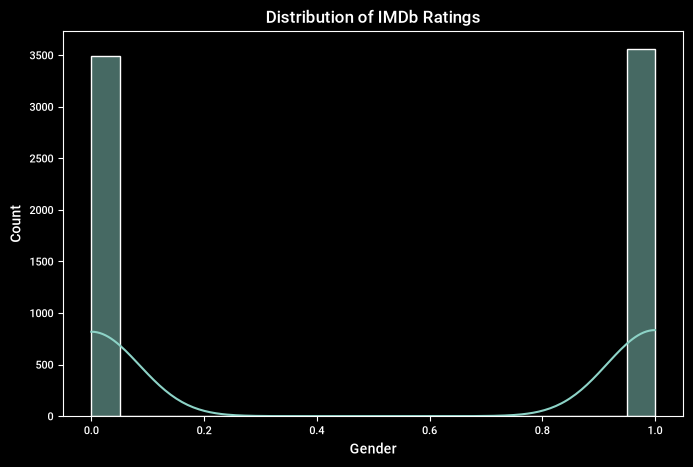

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['gender'], bins=20, kde=True)
plt.title("Distribution of IMDb Ratings")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='Contract_One year', ylabel='count'>

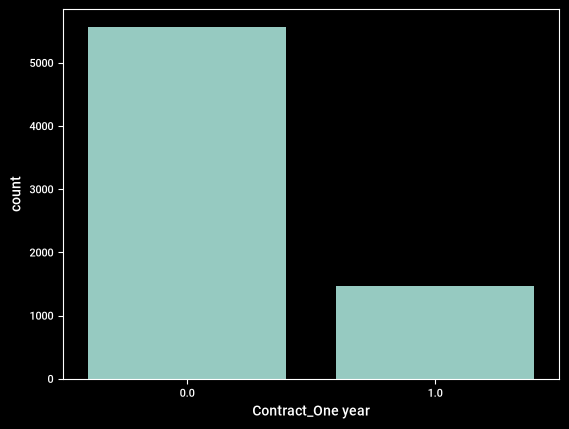

In [23]:
sns.countplot(data=df,x="Contract_One year")

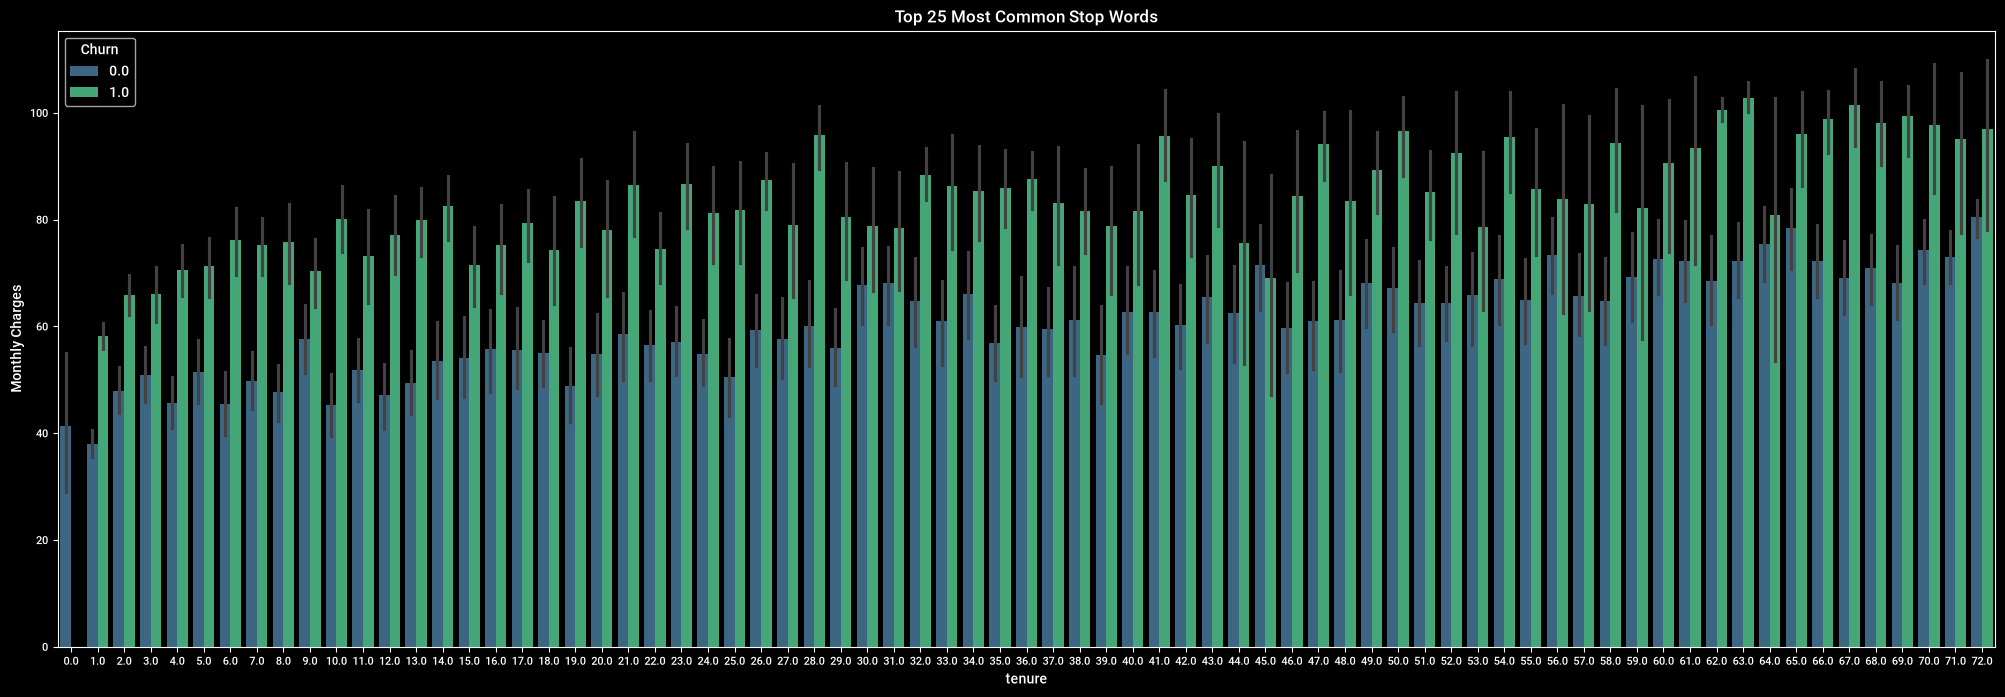

In [24]:
plt.figure(figsize=(25, 8))
sns.barplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn',palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('tenure')
plt.ylabel('Monthly Charges')
plt.show()


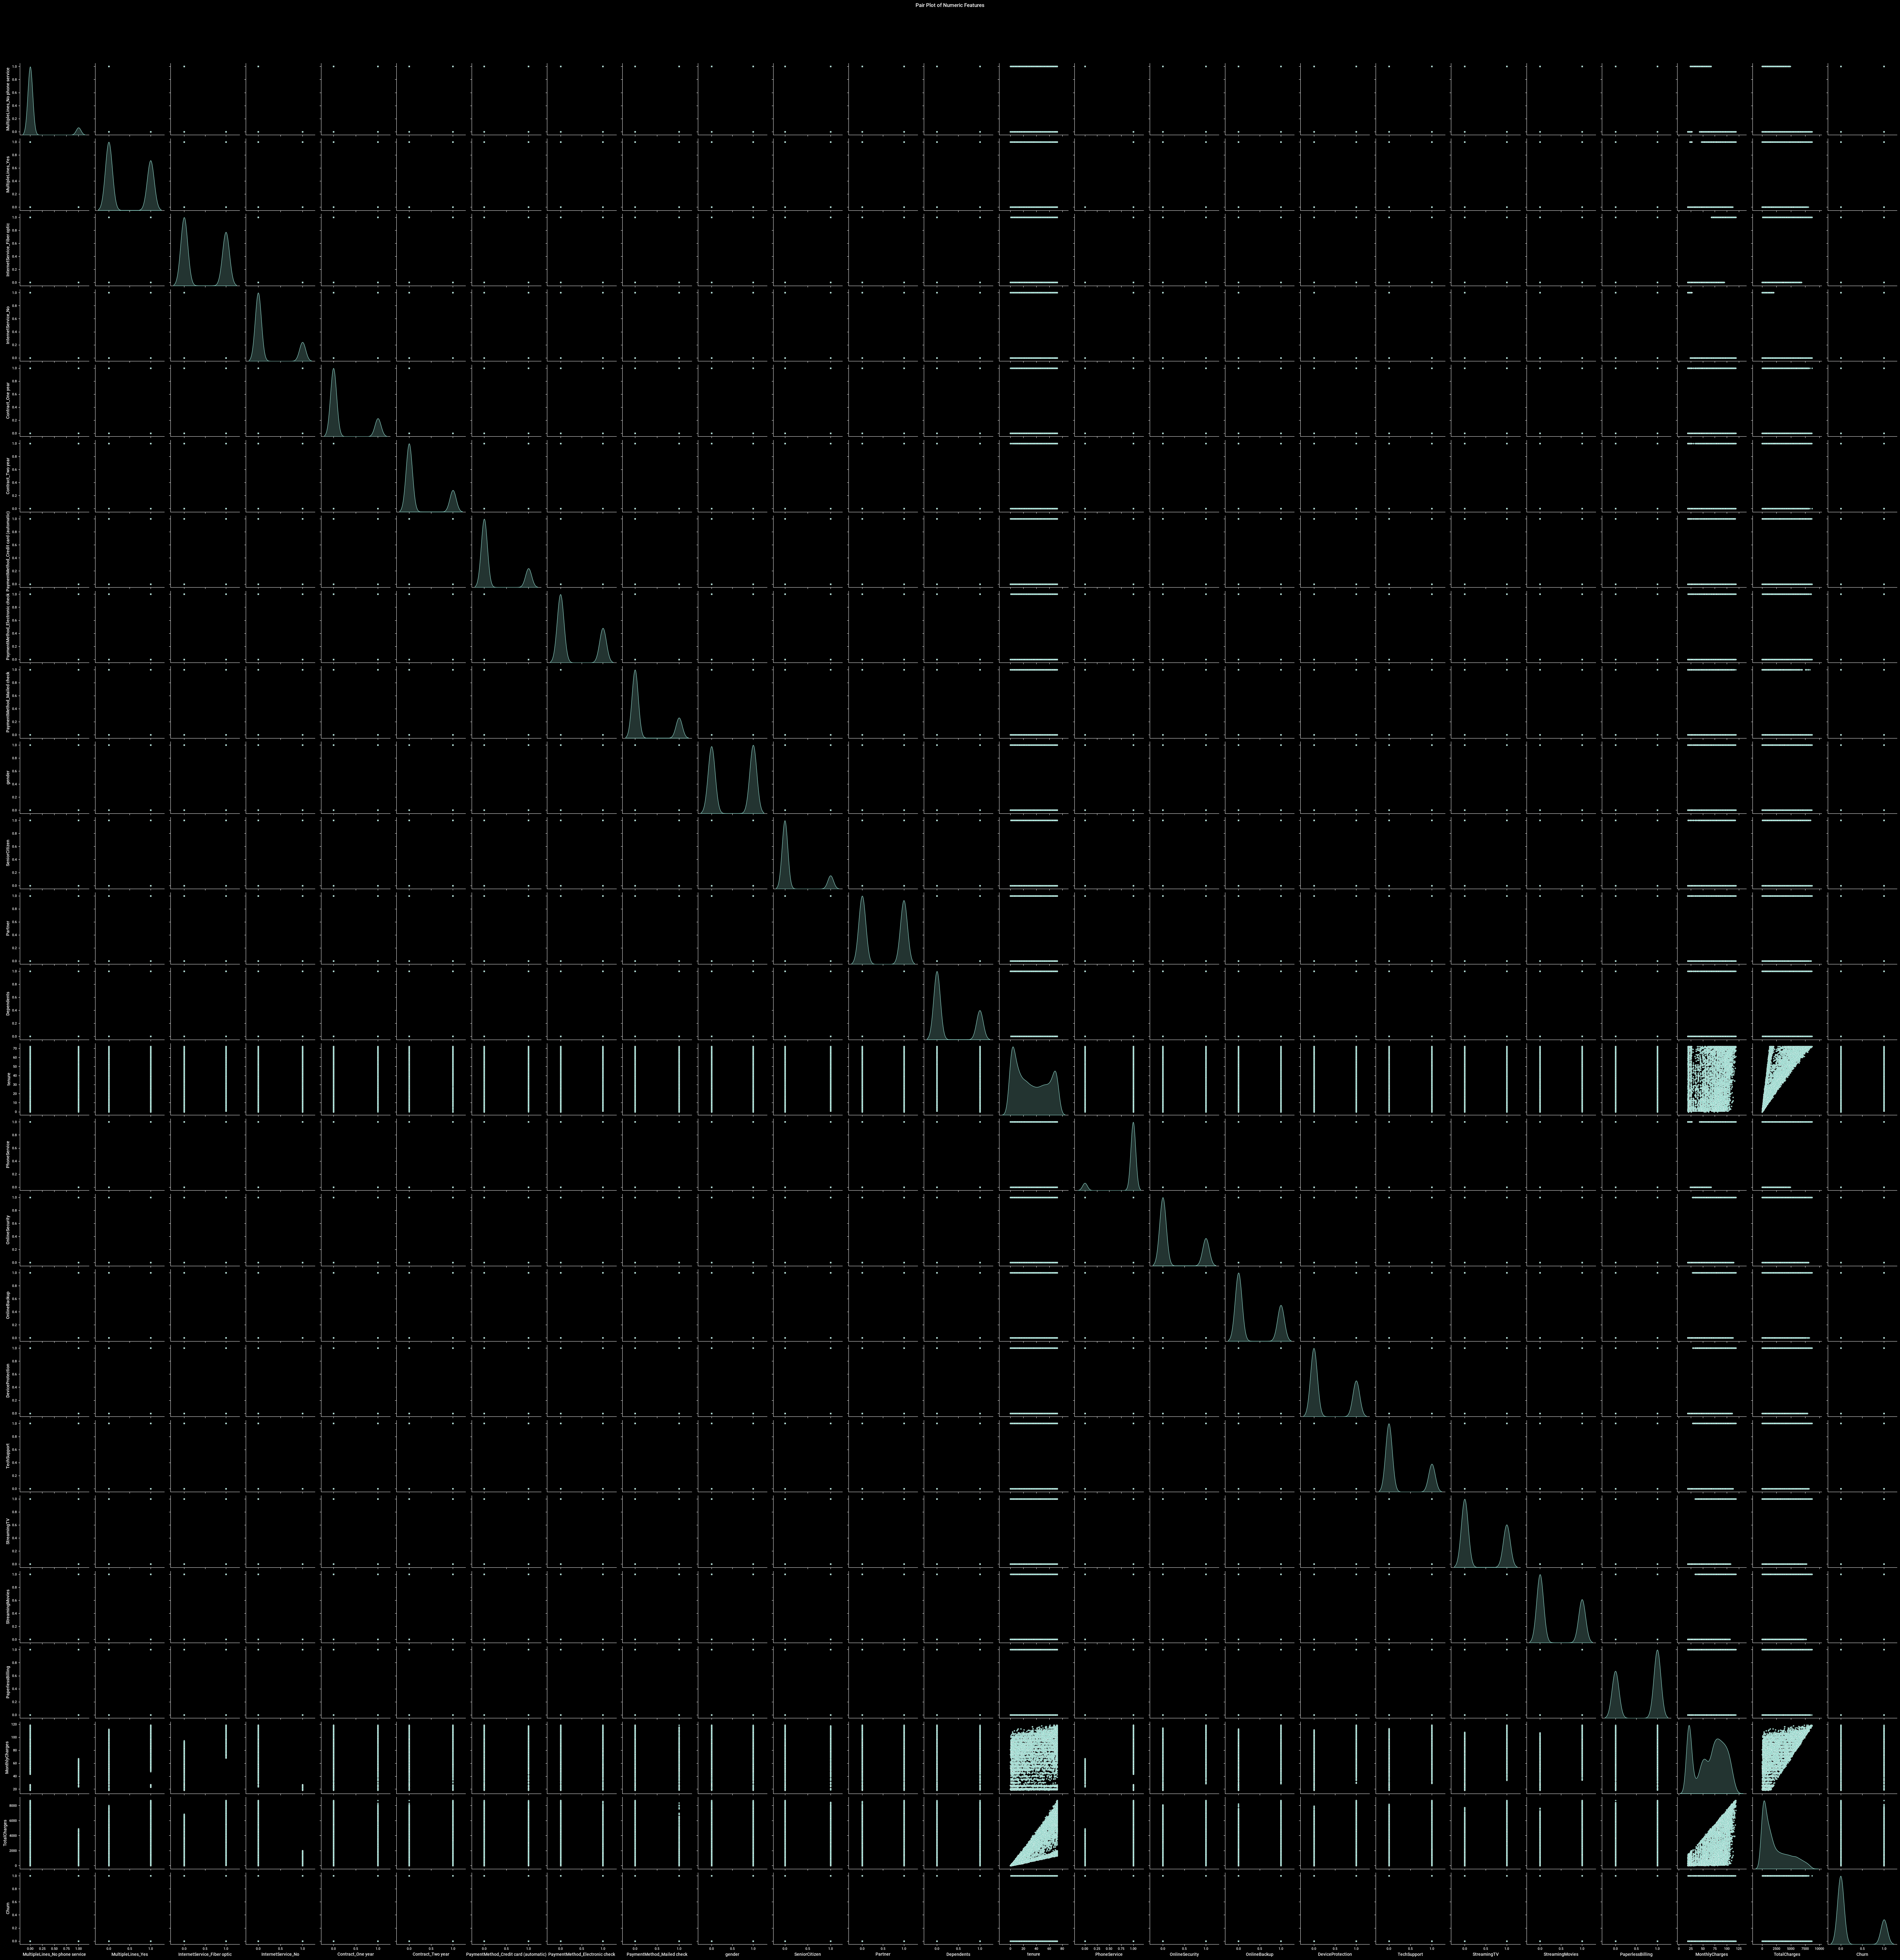

In [25]:
numeric_df = df.select_dtypes(include=[np.number])
sns.pairplot(numeric_df, diag_kind='kde')
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

                                       MultipleLines_No phone service  \
MultipleLines_No phone service                               1.000000   
MultipleLines_Yes                                           -0.279690   
InternetService_Fiber optic                                 -0.289999   
InternetService_No                                          -0.172209   
Contract_One year                                            0.002791   
Contract_Two year                                           -0.003519   
PaymentMethod_Credit card (automatic)                        0.007721   
PaymentMethod_Electronic check                              -0.003062   
PaymentMethod_Mailed check                                   0.003319   
gender                                                       0.006488   
SeniorCitizen                                               -0.008576   
Partner                                                     -0.017706   
Dependents                                         

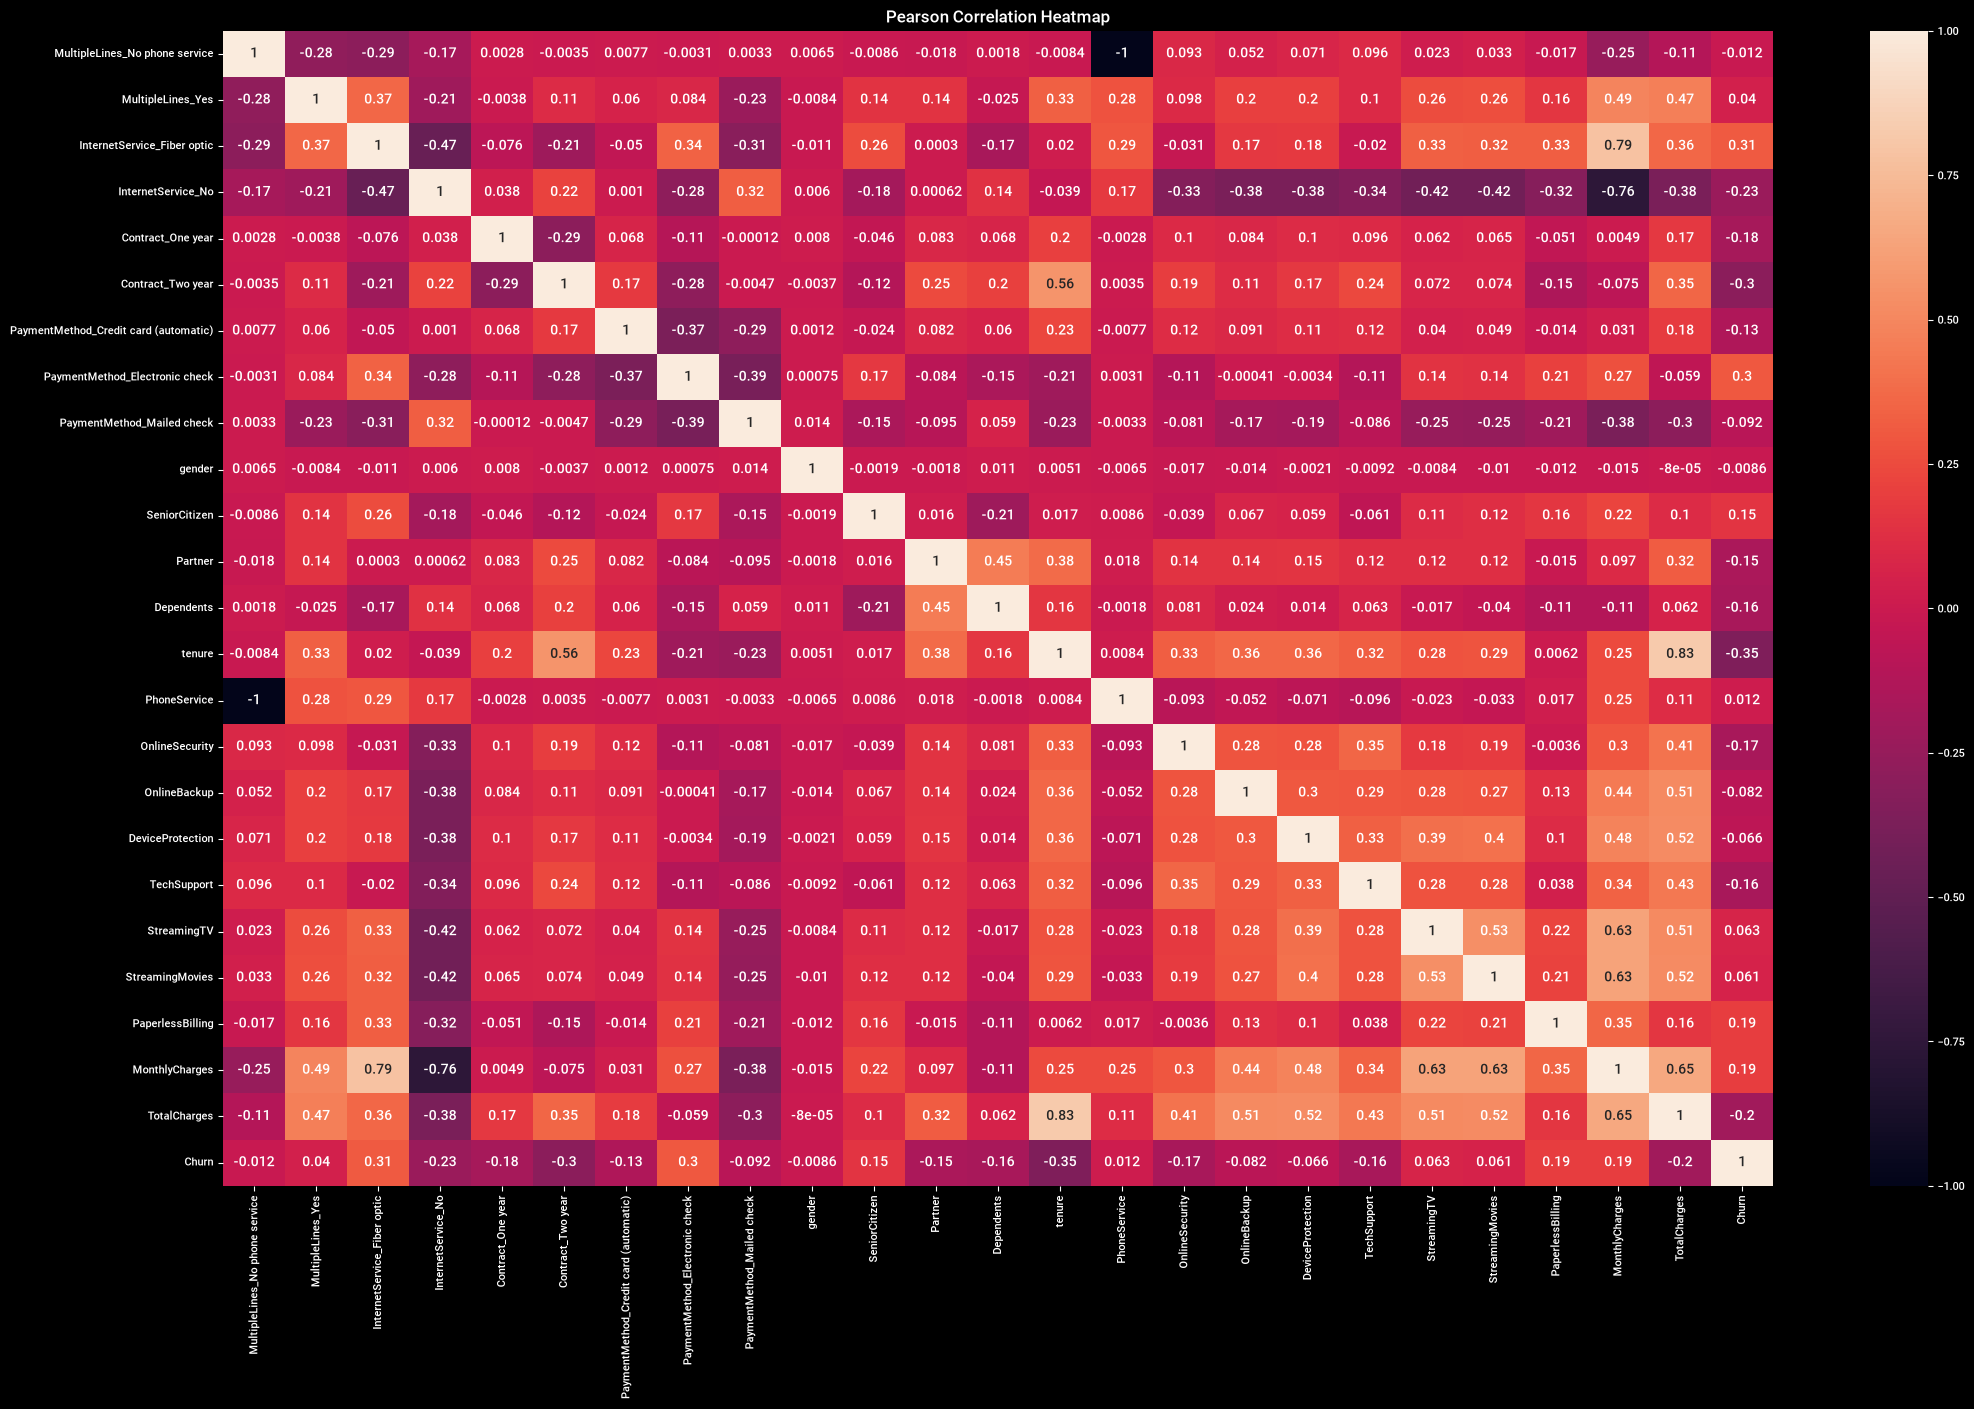

In [32]:
plt.figure(figsize=(25, 15))
df_corr = numeric_df.corr()
print(df_corr)

sns.heatmap(df_corr, annot=True)
plt.title("Pearson Correlation Heatmap")
plt.show()